In [6]:
#生成DB和SDDB
import pandas as pd

DB = pd.read_csv("DB_VADER.csv")
DB_subset = DB[["Series","Dream_Text","Word_Count"]]
DB_subset.to_csv("DB.csv", index=False, encoding = "utf-8")

SDDB = pd.read_csv("SDDB_VADER.csv")
SDDB_subset = SDDB[["Survey Name","Dream Text","Word Count"]]
SDDB_subset.to_csv("SDDB.csv", index=False, encoding = "utf-8")

In [14]:
#生成DB_EMPATH

%pip install empath

from empath import Empath
import pandas as pd

lexicon = Empath()

DB = pd.read_csv("DB.csv")
DB_theme = DB["Dream_Text"].apply(lambda x: lexicon.analyze(x, normalize=True))
DB_theme_df = pd.DataFrame(DB_theme.tolist())
DB_EMPATH = pd.concat([DB, DB_theme_df], axis = 1)
DB_EMPATH.to_csv("DB_EMPATH.csv", index = False, encoding = "utf-8")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
#生成SDDB_EMPATH
%pip install empath

from empath import Empath
import pandas as pd

lexicon = Empath()

SDDB = pd.read_csv("SDDB.csv")
SDDB_theme = SDDB["Dream Text"].apply(lambda x: lexicon.analyze(x, normalize=True))
SDDB_theme_df = pd.DataFrame(SDDB_theme.tolist())
SDDB_EMPATH = pd.concat([SDDB, SDDB_theme_df], axis = 1)
SDDB_EMPATH.to_csv("SDDB_EMPATH.csv", index = False, encoding = "utf-8")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 生成DB_SPACY和SDDB_SPACY
# 这是在kaggle上跑的
%pip install spacy
%python -m spacy download en_core_web_sm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 11.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 658.0/658.0 kB 17.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.4/815.4 kB 20.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.8 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [spacy]m15/16 [spacy]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


正在计算交叉比例并绘制 100% 堆叠柱状图...


KeyError: 'KMeans_Cluster_3'

In [35]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ==========================================
# 0. 绝对红线：特征标准化！
# （K-Means 是基于距离计算的，如果不标准化，word_count 这种几百的数字会直接吃掉所有权重）
# ==========================================
print("正在标准化特征...")
X = analysis_df[valid_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 1. 跑 K-Means = 3 (正向、负向、中性社交)
# ==========================================
print("正在执行 K-Means=3 的聚类...")
k_num = 3 
# random_state=42 保证你每次跑出来的结果（也就是那张冷暖色表）都是一样的
kmeans = KMeans(n_clusters=k_num, random_state=42, n_init=10)

# 拟合并生成聚类标签
clusters = kmeans.fit_predict(X_scaled)

# 把标签存回 DataFrame，加个前缀方便后续画图和打标签
analysis_df['KMeans_Cluster_3'] = ['Cluster ' + str(c) for c in clusters]

# ==========================================
# 2. 打印最核心的“特征画像表”
# ==========================================
print("\n=== 各个 Cluster 的特征画像 (均值) ===")
cluster_profile_3 = analysis_df.groupby('KMeans_Cluster_3')[valid_features].mean()

# 使用 display 和 style.background_gradient 画出带冷暖色的表格（在 Jupyter 里直接渲染）
display(cluster_profile_3.style.background_gradient(cmap='coolwarm', axis=0))

# 顺便打印一下各簇的样本量
print("\n=== 各个 Cluster 的样本数量 ===")
print(analysis_df['KMeans_Cluster_3'].value_counts())

正在标准化特征...
正在执行 K-Means=3 的聚类...

=== 各个 Cluster 的特征画像 (均值) ===


,word_count,verb_ratio,adj_ratio,compound,violence,family,health,movement,negative_emotion,friends,communication,death
KMeans_Cluster_3,,,,,,,,,,,,
Cluster 0,96.383126,0.174372,0.046962,-0.362058,0.003454,0.006631,0.001021,0.005019,0.009488,0.002802,0.004305,0.001602
Cluster 1,29.524281,0.171440,0.071680,-0.373081,0.040212,0.029807,0.003230,0.005953,0.066430,0.010967,0.002939,0.036617
Cluster 2,158.548371,0.141024,0.070521,0.639449,0.001649,0.005461,0.000598,0.004009,0.004230,0.006624,0.004437,0.001130



=== 各个 Cluster 的样本数量 ===
KMeans_Cluster_3
Cluster 2    17924
Cluster 0    16475
Cluster 1     1112
Name: count, dtype: int64


正在计算交叉比例并绘制 100% 堆叠柱状图...


/var/folders/cz/02dcqjtd6jsfwp_yjz_drwjw0000gn/T/ipykernel_31362/357687728.py:91: UserWarning:

Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) Arial.

/var/folders/cz/02dcqjtd6jsfwp_yjz_drwjw0000gn/T/ipykernel_31362/357687728.py:91: UserWarning:

Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) Arial.

/var/folders/cz/02dcqjtd6jsfwp_yjz_drwjw0000gn/T/ipykernel_31362/357687728.py:91: UserWarning:

Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) Arial.

/var/folders/cz/02dcqjtd6jsfwp_yjz_drwjw0000gn/T/ipykernel_31362/357687728.py:91: UserWarning:

Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) Arial.

/var/folders/cz/02dcqjtd6jsfwp_yjz_drwjw0000gn/T/ipykernel_31362/357687728.py:91: UserWarning:

Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from font(s) Arial.

/var/folders/cz/02dcqjtd6jsfwp_yjz_drwjw0000gn/T/ipykernel_31362/357687728.py:91: UserWarning:

Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing f

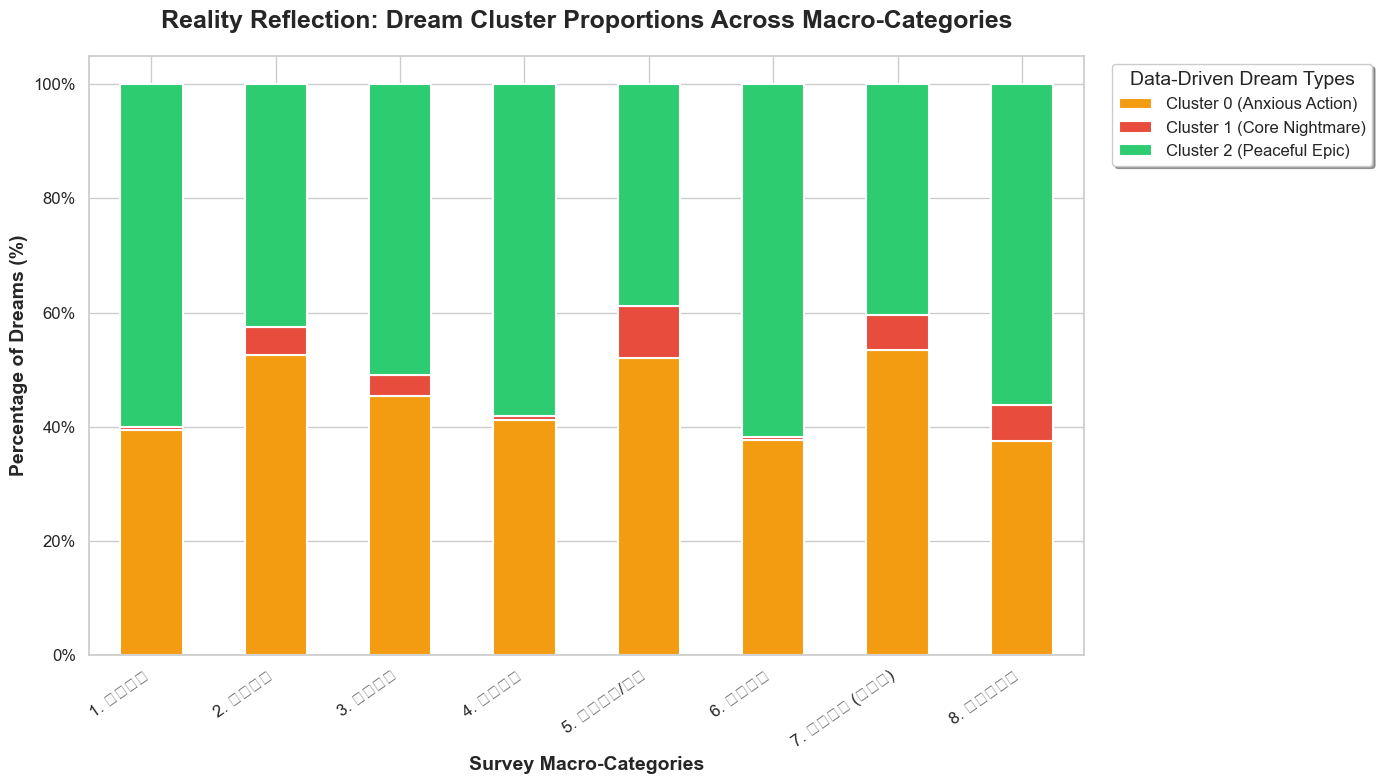

高清图表绘制完毕！


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 系统最稳的中文字体 (Win 一般用 'SimHei')
plt.rcParams['axes.unicode_minus'] = False # 顺便解决如果有负号显示不出的问题

print("正在计算交叉比例并绘制 100% 堆叠柱状图...")

# ==========================================
# 1. 数据准备与交叉表计算
# ==========================================
# crosstab 计算频数，normalize='index' 将每一行（每个宏观人群）的总和归一化为 1
# 然后乘以 100 转换为百分比
crosstab_df = pd.crosstab(
    analysis_df['Macro_Category'], 
    analysis_df['KMeans_Cluster_3'], 
    normalize='index'
) * 100

# 强制按照 8 大类别的逻辑顺序进行排序
category_order = [
    "1. 普通个人", "2. 普通人群", "3. 特殊人群", "4. 特殊个人", 
    "5. 特殊时代/背景", "6. 针对对象", "7. 特殊类型 (如噩梦)", "8. 非真实梦境"
]
# 过滤并排序，保证 X 轴的顺序是你想要的
crosstab_df = crosstab_df.reindex(category_order).dropna()


# ==========================================
# 2. 高级可视化设置
# ==========================================
# 设置 Seaborn 的基础风格
sns.set_theme(style="whitegrid")

# 🎯 核心视觉设计：为你破译的 3 个 Cluster 赋予符合直觉的颜色
# 注意：你需要根据上面跑出来的真实 Cluster 序号来对应这里的颜色
# 假设按照我们之前的推演：C0=焦虑挣扎(橙), C1=创伤噩梦(红), C2=积极叙事(绿)
custom_colors = ['#f39c12', '#e74c3c', '#2ecc71'] 

# 开始画图
fig, ax = plt.subplots(figsize=(14, 8))

crosstab_df.plot(
    kind='bar', 
    stacked=True, 
    ax=ax,
    color=custom_colors, 
    edgecolor='white', # 给柱子之间加上白色描边，显得更精致
    linewidth=1.5
)


# ==========================================
# 3. 细节装饰与学术规范
# ==========================================
plt.title('Reality Reflection: Dream Cluster Proportions Across Macro-Categories', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Survey Macro-Categories', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Dreams (%)', fontsize=14, fontweight='bold')

# 自动在 Y 轴数字后面加上 "%" 符号
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# X 轴标签旋转 35 度，并让字体右对齐，防止文字挤在一起
plt.xticks(rotation=35, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# 🎯 重命名图例（把机器生成的标签换成你大作业的核心洞察）
handles, labels = ax.get_legend_handles_labels()
# 请根据实际 K-Means 均值表，修改这里的名字和顺序
custom_legend_labels = [
    'Cluster 0 (Anxious Action)', 
    'Cluster 1 (Core Nightmare)', 
    'Cluster 2 (Peaceful Epic)'
]
plt.legend(
    handles, 
    custom_legend_labels, 
    title='Data-Driven Dream Types',
    bbox_to_anchor=(1.02, 1), # 把图例放到画布外面右侧
    loc='upper left', 
    frameon=True, 
    shadow=True, 
    fontsize=12, 
    title_fontsize=14
)

# 自动调整边距，防止外置的图例或旋转的标签被切掉
plt.tight_layout()

# 保存为 300dpi 的高清图片，方便直接贴入 Word 或 PPT
plt.savefig("Dream_Clusters_100_Stacked_Bar.png", dpi=300, bbox_inches='tight')
plt.show()

print("高清图表绘制完毕！")